<a href="https://colab.research.google.com/github/MartinCarossino/analisis-peliculas-tmdb/blob/main/analisis_peliculas_tmdb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis exploratorio de películas — TMDB 5000

Este proyecto analiza casi 5.000 películas del dataset público **TMDB 5000 Movie Dataset**,
cruzando dos fuentes distintas: datos financieros/descriptivos (`tmdb_5000_movies.csv`) y
datos de reparto/equipo de producción (`tmdb_5000_credits.csv`).

**Preguntas que guían el análisis:**
- ¿Qué tan relacionados están presupuesto, ingresos, popularidad y rating?
- ¿Qué géneros tienen mejor retorno de inversión (ROI) real, no inflado por outliers?
- ¿Cambió la relación entre presupuesto e ingresos a lo largo de las décadas?

**Estructura del notebook (5 bloques):**
1. Ingesta, limpieza y merge real entre ambas fuentes
2. Carga a SQLite vía SQLAlchemy + verificación del merge con SQL puro
3. Encoding categórico (género y rango de rating)
4. Estadística descriptiva, correlaciones y análisis de ROI
5. Visualización con Seaborn y conclusiones

**Fuente de datos:** [TMDB 5000 Movie Dataset (Kaggle)](https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata),
alojado en este repo para que el notebook sea reproducible sin descargas manuales.

## Bloque 1 — Ingesta, limpieza y merge

Cargamos las dos fuentes y las unimos por su clave real (`id` ↔ `movie_id`), no por título
(evita colisiones si hay nombres duplicados).

Un punto clave de limpieza: `budget=0` y `revenue=0` no son ceros reales — significan
"sin dato". Los convertimos a `NaN` en vez de borrar esas filas, porque eliminarlas haría
perder ~30% del dataset solo por falta de un dato financiero, cuando esas películas siguen
siendo válidas para analizar género, rating o duración.

También parseamos las columnas `genres`, `cast` y `crew`, que llegan como texto con formato
JSON en vez de datos tabulares directos.

In [7]:
# ============================================================
# BLOQUE 1 — INGESTA, LIMPIEZA Y MERGE
# Proyecto: Análisis de películas TMDB 5000
# ============================================================
#
# Dataset original: "TMDB 5000 Movie Dataset" (Kaggle, autor: tmdb)
# https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata
#
# Los CSV están alojados en GitHub para que el notebook sea
# 100% reproducible (no requiere descargar nada a mano):
# https://github.com/MartinCarossino/analisis-peliculas-tmdb
# ============================================================

import pandas as pd
import numpy as np
import ast  # para parsear las columnas que vienen como texto con formato de lista/diccionario

# ------------------------------------------------------------
# 1.1 — Carga de los dos archivos
# ------------------------------------------------------------
# Cada archivo es UNA fuente de datos distinta:
#   - movies: datos financieros y descriptivos de la película
#   - credits: reparto (cast) y equipo de producción (crew)
# No están en el mismo archivo a propósito: simulan dos fuentes
# que en un caso real podrían venir de sistemas distintos
# (por ej. un sistema financiero y un sistema de producción).

URL_MOVIES = 'https://raw.githubusercontent.com/MartinCarossino/analisis-peliculas-tmdb/main/tmdb_5000_movies.csv'
URL_CREDITS = 'https://raw.githubusercontent.com/MartinCarossino/analisis-peliculas-tmdb/main/tmdb_5000_credits.csv'

movies = pd.read_csv(URL_MOVIES)
credits = pd.read_csv(URL_CREDITS)

print("movies:", movies.shape)
print("credits:", credits.shape)

# ------------------------------------------------------------
# 1.2 — Inspección inicial
# ------------------------------------------------------------
# Siempre antes de tocar nada: entender qué tenemos.

movies.info()
print("\n--- Nulos en movies ---")
print(movies.isnull().sum().sort_values(ascending=False).head(10))

credits.info()
print("\n--- Nulos en credits ---")
print(credits.isnull().sum())

# Duplicados por id (no deberían existir, pero se chequea siempre)
print("\nDuplicados en movies por id:", movies['id'].duplicated().sum())
print("Duplicados en credits por movie_id:", credits['movie_id'].duplicated().sum())

# ------------------------------------------------------------
# 1.3 — Merge real entre las dos fuentes
# ------------------------------------------------------------
# Clave de unión: movies.id <-> credits.movie_id
# Usamos 'id' en vez de 'title' porque puede haber títulos
# duplicados (remakes, etc.) y el id es único.

credits_renombrado = credits.rename(columns={'movie_id': 'id'})

# Antes del merge, sacamos 'title' de credits para no duplicar
# la columna (ya está en movies) — quedan title_x / title_y si no lo hacemos.
credits_renombrado = credits_renombrado.drop(columns=['title'])

df = movies.merge(credits_renombrado, on='id', how='inner')

print("\nForma del dataframe combinado:", df.shape)
# Esperamos seguir con ~4803 filas: el merge no debería perder
# ni duplicar filas porque la clave es 1 a 1 en ambos lados.

# ------------------------------------------------------------
# 1.4 — Limpieza de presupuesto e ingresos
# ------------------------------------------------------------
# budget=0 o revenue=0 NO son nulos técnicamente, pero
# significan "sin dato" (nadie hace una película con
# presupuesto real de $0). Los tratamos como datos faltantes
# para no distorsionar correlaciones y ROI más adelante.

print("\nPelículas con budget = 0:", (df['budget'] == 0).sum())
print("Películas con revenue = 0:", (df['revenue'] == 0).sum())

# Los marcamos como NaN en vez de borrar la fila directamente:
# así conservamos la película para análisis que no dependan
# de esas dos columnas (ej. análisis de géneros o duración).
df['budget'] = df['budget'].replace(0, np.nan)
df['revenue'] = df['revenue'].replace(0, np.nan)

# ------------------------------------------------------------
# 1.5 — Parseo de columnas JSON-string
# ------------------------------------------------------------
# genres, keywords, cast y crew vienen como texto que PARECE
# JSON pero pandas lo lee como string plano. Ejemplo real:
#   '[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}]'
#
# ast.literal_eval() convierte ese string en una lista de
# diccionarios de Python real, sin los riesgos de seguridad
# de usar eval().

def extraer_nombres(texto_json, limite=None):
    """
    Convierte un string tipo JSON (lista de diccionarios con
    clave 'name') en una lista simple de nombres.

    texto_json: el string crudo de la columna (ej. genres, cast)
    limite: si se pasa, corta la lista a los primeros N elementos
            (útil para 'cast', donde solo nos interesan los
            actores principales, no los 50 secundarios)
    """
    try:
        lista_dicts = ast.literal_eval(texto_json)
    except (ValueError, SyntaxError):
        return []

    nombres = [d['name'] for d in lista_dicts]

    if limite is not None:
        nombres = nombres[:limite]

    return nombres


def extraer_director(texto_crew):
    """
    El crew incluye TODOS los roles (editor, sonido, fotografía, etc.).
    Para nuestro análisis nos interesa puntualmente quién dirigió,
    así que filtramos por job == 'Director'.
    """
    try:
        lista_dicts = ast.literal_eval(texto_crew)
    except (ValueError, SyntaxError):
        return None

    for persona in lista_dicts:
        if persona.get('job') == 'Director':
            return persona['name']

    return None  # por si no hay director listado


df['lista_generos'] = df['genres'].apply(extraer_nombres)
df['genero_principal'] = df['lista_generos'].apply(
    lambda lista: lista[0] if len(lista) > 0 else 'Sin género'
)

df['reparto_principal'] = df['cast'].apply(lambda x: extraer_nombres(x, limite=3))
df['director'] = df['crew'].apply(extraer_director)

# ------------------------------------------------------------
# 1.6 — Features derivadas simples
# ------------------------------------------------------------
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['anio_estreno'] = df['release_date'].dt.year
df['decada_estreno'] = (df['anio_estreno'] // 10) * 10

# ROI: cuánto generó la película en relación a lo que costó.
# Solo calculable donde tenemos budget y revenue reales (no NaN).
df['roi'] = (df['revenue'] - df['budget']) / df['budget']

# ------------------------------------------------------------
# 1.7 — Selección de columnas relevantes para el análisis
# ------------------------------------------------------------
columnas_finales = [
    'id', 'title', 'genero_principal', 'director', 'reparto_principal',
    'budget', 'revenue', 'roi', 'popularity', 'vote_average', 'vote_count',
    'runtime', 'original_language', 'anio_estreno', 'decada_estreno'
]

df_final = df[columnas_finales].copy()

print("\n--- Vista final ---")
print(df_final.head())
print("\nForma final:", df_final.shape)
print("\nNulos por columna:")
print(df_final.isnull().sum())

# df_final queda listo para el Bloque 2 (carga a SQLite)

movies: (4803, 20)
credits: (4803, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-nul

## Bloque 2 — SQLite + SQLAlchemy

Volcamos las tablas crudas (sin mergear en pandas) a una base SQLite, y reproducimos el
mismo cruce con un `INNER JOIN` en SQL puro. La idea es demostrar que el merge de pandas y
el JOIN de SQL son la misma operación relacional expresada en dos sintaxis distintas — y lo
confirmamos comparando que ambos caminos dan exactamente la misma cantidad de filas.

A partir de ahí, dejamos que la base haga el trabajo analítico pesado (agregaciones,
filtros, ordenamientos) en vez de traer todo a Python y procesarlo ahí — filosofía SQL-first.

In [3]:
# ============================================================
# BLOQUE 2 — CARGA A SQLite + SQLAlchemy + read_sql()
# Proyecto: Análisis de películas TMDB 5000
# ============================================================
#
# Este bloque asume que ya corriste el Bloque 1 y tenés en
# memoria los dataframes 'movies' y 'credits' (los crudos,
# ANTES del merge de pandas). La idea es reproducir el mismo
# cruce de fuentes, pero esta vez con SQL real, para comparar
# ambos caminos y mostrar que llegan al mismo resultado.
# ============================================================

from sqlalchemy import create_engine, text
import pandas as pd

# ------------------------------------------------------------
# 2.1 — Crear el motor de base de datos
# ------------------------------------------------------------
# SQLite no necesita un servidor: la "base" puede vivir en un
# archivo local. La usamos como si fuera una base real para
# practicar el flujo completo (engine -> tablas -> consultas).
#
# 'sqlite:///tmdb_peliculas.db' crea (o abre, si ya existe)
# un archivo .db en el disco. Si preferís que no quede ningún
# archivo después de correr el notebook, se puede usar
# 'sqlite:///:memory:' (la base vive solo en RAM y se borra
# al cerrar el kernel).

engine = create_engine('sqlite:///tmdb_peliculas.db')

# ------------------------------------------------------------
# 2.2 — Volcar los dataframes crudos a tablas SQL
# ------------------------------------------------------------
# Mandamos 'movies' y 'credits' SIN mergear todavía: el join
# lo vamos a hacer en SQL para practicar esa lógica ahí, no
# en pandas. Esto es justamente el punto del bloque: nuestro
# dataframe combinado del Bloque 1 demuestra que sabemos
# hacerlo con pandas, y este bloque demuestra que sabemos
# hacerlo también con SQL puro.

movies.to_sql('movies', engine, if_exists='replace', index=False)
credits.to_sql('credits', engine, if_exists='replace', index=False)

print("Tablas cargadas en SQLite: movies, credits")

# ------------------------------------------------------------
# 2.3 — Verificación rápida: leer las tablas con read_sql()
# ------------------------------------------------------------
# pd.read_sql() acepta tanto un nombre de tabla simple como
# una consulta SQL completa. Empezamos simple, confirmando
# que los datos llegaron bien.

chequeo_movies = pd.read_sql('SELECT COUNT(*) AS total_peliculas FROM movies', engine)
chequeo_credits = pd.read_sql('SELECT COUNT(*) AS total_creditos FROM credits', engine)

print(chequeo_movies)
print(chequeo_credits)

# ------------------------------------------------------------
# 2.4 — El JOIN real en SQL
# ------------------------------------------------------------
# Reproducimos el mismo cruce que hicimos con pd.merge() en el
# Bloque 1, pero ahora con un INNER JOIN explícito por la
# clave id / movie_id. Filosofía SQL-first: la lógica de
# combinar las dos fuentes vive en la consulta, no en un loop
# de Python.

query_join = """
SELECT
    m.id,
    m.title,
    m.budget,
    m.revenue,
    m.popularity,
    m.vote_average,
    m.vote_count,
    m.runtime,
    m.original_language,
    m.release_date,
    c.cast,
    c.crew
FROM movies AS m
INNER JOIN credits AS c
    ON m.id = c.movie_id
"""

df_sql = pd.read_sql(query_join, engine)

print("\nForma del resultado vía JOIN en SQL:", df_sql.shape)

# ------------------------------------------------------------
# 2.5 — Comparación: merge de pandas vs JOIN de SQL
# ------------------------------------------------------------
# Si ambos caminos están bien hechos, tienen que llegar al
# mismo número de filas. Esta comparación es la prueba de que
# entendemos que un merge en pandas y un JOIN en SQL son, en
# esencia, la misma operación relacional expresada en dos
# sintaxis distintas.

print("\nFilas via pd.merge() (Bloque 1):", df.shape[0])
print("Filas via JOIN SQL (Bloque 2):", df_sql.shape[0])

assert df.shape[0] == df_sql.shape[0], "Los dos caminos no coinciden: revisar claves de unión"
print("\n✓ Ambos métodos coinciden en cantidad de filas.")

# ------------------------------------------------------------
# 2.6 — Consultas analíticas directas en SQL
# ------------------------------------------------------------
# Acá es donde se nota la filosofía SQL-first: en vez de traer
# todo a pandas y filtrar/agrupar ahí, dejamos que la base
# haga el trabajo pesado y solo traemos el resultado ya
# resumido.

# Top 10 películas por ROI, solo considerando las que tienen
# budget y revenue reales (>0, no los "sin dato" que limpiamos
# en el Bloque 1).
query_top_roi = """
SELECT
    title,
    budget,
    revenue,
    ROUND((revenue - budget) * 1.0 / budget, 2) AS roi
FROM movies
WHERE budget > 0
  AND revenue > 0
ORDER BY roi DESC
LIMIT 10
"""

top_roi = pd.read_sql(query_top_roi, engine)
print("\n--- Top 10 películas por ROI ---")
print(top_roi)

# Presupuesto e ingreso promedio por década de estreno.
# strftime extrae el año desde release_date (formato YYYY-MM-DD)
# y lo agrupamos en décadas con aritmética entera.
query_por_decada = """
SELECT
    (CAST(strftime('%Y', release_date) AS INTEGER) / 10) * 10 AS decada,
    COUNT(*) AS cantidad_peliculas,
    ROUND(AVG(budget), 0) AS presupuesto_promedio,
    ROUND(AVG(revenue), 0) AS ingreso_promedio,
    ROUND(AVG(vote_average), 2) AS rating_promedio
FROM movies
WHERE release_date IS NOT NULL
  AND budget > 0
  AND revenue > 0
GROUP BY decada
ORDER BY decada
"""

resumen_por_decada = pd.read_sql(query_por_decada, engine)
print("\n--- Resumen por década (solo películas con budget/revenue reales) ---")
print(resumen_por_decada)

# df_sql queda disponible para comparar contra df_final del
# Bloque 1 si se quiere profundizar más adelante.

Tablas cargadas en SQLite: movies, credits
   total_peliculas
0             4803
   total_creditos
0            4803

Forma del resultado vía JOIN en SQL: (4803, 12)

Filas via pd.merge() (Bloque 1): 4803
Filas via JOIN SQL (Bloque 2): 4803

✓ Ambos métodos coinciden en cantidad de filas.

--- Top 10 películas por ROI ---
                     title  budget    revenue         roi
0             Modern Times       1    8500000  8499999.00
1                Nurse 3-D      10   10000000   999999.00
2      Paranormal Activity   15000  193355800    12889.39
3                Tarnation     218    1162014     5329.34
4  The Blair Witch Project   60000  248000000     4132.33
5               Eraserhead   10000    7000000      699.00
6           Pink Flamingos   12000    6000000      499.00
7            Super Size Me   65000   28575078      438.62
8              The Gallows  100000   42664410      425.64
9               Open Water  130000   54667954      419.52

--- Resumen por década (solo película

## Bloque 3 — Encoding categórico

No todas las variables categóricas se codifican igual. La elección depende de si la
categoría tiene un orden natural:

- **`OneHotEncoder`** para género de película (`genero_principal`): no existe una jerarquía
  entre "Comedy" y "Drama", son categorías paralelas (nominales).
- **`OrdinalEncoder`** para rango de rating (`bajo` / `medio` / `alto`): acá sí hay una
  jerarquía real, y hay que especificarla a mano — por defecto el encoder ordena
  alfabéticamente, lo que invertiría la escala real (`alto` terminaría valiendo 0).

In [4]:
# ============================================================
# BLOQUE 3 — ENCODING CATEGÓRICO
# Proyecto: Análisis de películas TMDB 5000
# ============================================================
#
# Este bloque asume que ya corriste los Bloques 1 y 2, y que
# tenés en memoria 'df_final' (el dataframe limpio del Bloque 1).
#
# Idea central: no todas las columnas categóricas se codifican
# igual. Elegimos la técnica según si la categoría tiene un
# ORDEN natural o no:
#
#   - Sin orden natural (nominal)  -> OneHotEncoder
#     Ej: género de la película (Action, Drama, Comedy...)
#     No existe un "Action > Drama"; son categorías paralelas.
#
#   - Con orden natural (ordinal)  -> OrdinalEncoder
#     Ej: rango de rating (bajo / medio / alto)
#     Acá SÍ existe una jerarquía real: alto > medio > bajo.
# ============================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# ------------------------------------------------------------
# 3.1 — Repaso rápido de la columna a codificar (nominal)
# ------------------------------------------------------------
print("--- Distribución de género principal ---")
print(df_final['genero_principal'].value_counts())

# ------------------------------------------------------------
# 3.2 — OneHotEncoder para género (categoría SIN orden)
# ------------------------------------------------------------
# OneHotEncoder convierte cada categoría en su propia columna
# binaria (0/1). Es la opción correcta cuando las categorías
# son nominales: no tiene sentido decir que "Comedy" vale más
# o menos que "Drama" en una escala numérica.
#
# sparse_output=False: devuelve un array denso (más fácil de
# leer en un dataframe chico como este). En datasets gigantes
# con muchas categorías se preferiría dejarlo en formato sparse
# para ahorrar memoria.

encoder_genero = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# El encoder espera una matriz 2D (filas, columnas), por eso
# le pasamos df_final[['genero_principal']] con doble corchete
# en vez de df_final['genero_principal'] (que sería 1D).
generos_codificados = encoder_genero.fit_transform(df_final[['genero_principal']])

# get_feature_names_out() nos da los nombres de columna
# correctos (ej. 'genero_principal_Action', 'genero_principal_Drama', ...)
nombres_columnas_genero = encoder_genero.get_feature_names_out(['genero_principal'])

df_genero_onehot = pd.DataFrame(
    generos_codificados,
    columns=nombres_columnas_genero,
    index=df_final.index
)

print("\n--- One-Hot de género (primeras filas, primeras columnas) ---")
print(df_genero_onehot.iloc[:5, :6])
print("\nCantidad de columnas generadas:", df_genero_onehot.shape[1])

# ------------------------------------------------------------
# 3.3 — Crear la columna ordinal: rango de rating
# ------------------------------------------------------------
# vote_average va de 0 a 10. Lo discretizamos en 3 rangos con
# un orden real: bajo < medio < alto. Los puntos de corte
# (5 y 7) son una elección razonable y común en este dataset
# (la mayoría de las películas rondan 5-7), no un estándar
# universal — se pueden ajustar según el análisis que se quiera
# resaltar.

def clasificar_rating(valor):
    if pd.isna(valor):
        return np.nan
    elif valor < 5:
        return 'bajo'
    elif valor < 7:
        return 'medio'
    else:
        return 'alto'

df_final['rango_rating'] = df_final['vote_average'].apply(clasificar_rating)

print("\n--- Distribución de rango_rating ---")
print(df_final['rango_rating'].value_counts())

# ------------------------------------------------------------
# 3.4 — OrdinalEncoder para rango_rating (categoría CON orden)
# ------------------------------------------------------------
# A diferencia de OneHotEncoder, acá NO queremos perder la
# noción de orden creando columnas separadas. OrdinalEncoder
# asigna un número entero respetando la jerarquía que nosotros
# definimos explícitamente en 'categories'.
#
# Si no especificáramos 'categories', el encoder ordenaría
# alfabéticamente ('alto', 'bajo', 'medio') — y eso ROMPERÍA
# la jerarquía real (alto terminaría valiendo 0, lo más bajo
# de la escala). Por eso siempre hay que pasar el orden a mano.

encoder_rating = OrdinalEncoder(
    categories=[['bajo', 'medio', 'alto']],
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

# dropna() temporal solo para el encoder: no puede procesar NaN.
# Lo manejamos con una máscara para no perder el resto de las filas.
mascara_validas = df_final['rango_rating'].notna()

df_final['rango_rating_codificado'] = np.nan
df_final.loc[mascara_validas, 'rango_rating_codificado'] = encoder_rating.fit_transform(
    df_final.loc[mascara_validas, ['rango_rating']]
).flatten()

print("\n--- Verificación: rango_rating vs su código ---")
print(df_final[['title', 'vote_average', 'rango_rating', 'rango_rating_codificado']].head(8))

# Confirmamos que el orden quedó bien asignado:
# bajo=0, medio=1, alto=2
print("\nCategorías y su código asignado:")
print(df_final[['rango_rating', 'rango_rating_codificado']].drop_duplicates().sort_values('rango_rating_codificado'))

# ------------------------------------------------------------
# 3.5 — Dataframe final con encoding aplicado
# ------------------------------------------------------------
# Unimos las columnas one-hot de género al dataframe original,
# manteniendo también 'genero_principal' en texto plano (útil
# para gráficos legibles en el Bloque 5, donde no queremos
# leer "genero_principal_Action=1" en un eje).

df_encoded = pd.concat([df_final, df_genero_onehot], axis=1)

print("\nForma final con encoding aplicado:", df_encoded.shape)
print("\nColumnas nuevas agregadas:")
print(list(df_genero_onehot.columns) + ['rango_rating', 'rango_rating_codificado'])

# df_encoded queda listo para el Bloque 4 (estadística descriptiva)

--- Distribución de género principal ---
genero_principal
Drama              1207
Comedy             1042
Action              754
Adventure           339
Horror              300
Crime               195
Thriller            194
Animation           123
Fantasy             117
Romance             106
Science Fiction      96
Documentary          89
Family               56
Mystery              41
Music                34
Sin género           28
Western              27
History              25
War                  24
TV Movie              4
Foreign               2
Name: count, dtype: int64

--- One-Hot de género (primeras filas, primeras columnas) ---
   genero_principal_Action  genero_principal_Adventure  \
0                      1.0                         0.0   
1                      0.0                         1.0   
2                      1.0                         0.0   
3                      1.0                         0.0   
4                      1.0                         0.0   



## Bloque 4 — Estadística descriptiva y correlaciones

Buscamos pasar de "tener los datos limpios" a "entender qué dicen". Tres ejes:

1. **Asimetría**: comparamos media vs mediana en presupuesto e ingresos para detectar si
   unos pocos outliers (superproducciones) están distorsionando el promedio.
2. **Correlaciones**: qué variables se mueven juntas (y aclaramos que correlación no es causalidad).
3. **ROI por género**: acá usamos la **mediana**, no el promedio — el ROI tiene outliers
   extremos (películas de presupuesto casi nulo con retornos absurdos), y el promedio queda
   completamente distorsionado por esos casos puntuales.

In [5]:
# ============================================================
# BLOQUE 4 — ESTADÍSTICA DESCRIPTIVA Y RELACIONES
# Proyecto: Análisis de películas TMDB 5000
# ============================================================
#
# Este bloque asume que ya corriste los Bloques 1, 2 y 3, y
# que tenés en memoria 'df_encoded' (o 'df_final', según qué
# columnas necesites — acá usamos principalmente df_final
# porque no necesitamos las columnas one-hot para esta parte).
#
# Objetivo: pasar de "tener los datos limpios" a "entender qué
# dicen los datos". Tres preguntas guían este bloque:
#   1. ¿Cómo se distribuyen las variables numéricas clave?
#   2. ¿Qué tan relacionadas están entre sí (correlación)?
#   3. ¿Qué géneros/décadas tienen mejor retorno (ROI)?
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 4.1 — Estadísticos descriptivos generales
# ------------------------------------------------------------
# .describe() da un primer pantallazo: media, mediana (50%),
# dispersión y extremos. Importante mirar la diferencia entre
# media y mediana: si son muy distintas, hay asimetría (outliers
# tirando el promedio hacia un lado).

columnas_numericas = ['budget', 'revenue', 'roi', 'popularity', 'vote_average', 'vote_count', 'runtime']

print("--- Estadísticos descriptivos generales ---")
print(df_final[columnas_numericas].describe().round(2))

# Comparación rápida media vs mediana en budget y revenue:
# si la media es mucho mayor que la mediana, confirma que hay
# unas pocas películas "mega-presupuesto" estirando el promedio.
print("\n--- Media vs Mediana (detecta asimetría) ---")
comparacion = pd.DataFrame({
    'media': df_final[['budget', 'revenue']].mean(),
    'mediana': df_final[['budget', 'revenue']].median()
})
print(comparacion.round(0))

# ------------------------------------------------------------
# 4.2 — Estadísticos por género principal
# ------------------------------------------------------------
# groupby + agg nos deja calcular varios estadísticos a la vez
# por cada categoría. Acá se ve la filosofía "que la base/pandas
# haga el trabajo pesado, no un loop manual".

estadisticas_por_genero = df_final.groupby('genero_principal').agg(
    cantidad=('id', 'count'),
    presupuesto_promedio=('budget', 'mean'),
    rating_promedio=('vote_average', 'mean'),
    popularidad_promedio=('popularity', 'mean'),
    roi_promedio=('roi', 'mean')
).round(2)

# Ordenamos por cantidad para ver primero los géneros con más
# muestra (más confiables estadísticamente).
estadisticas_por_genero = estadisticas_por_genero.sort_values('cantidad', ascending=False)

print("\n--- Estadísticas por género (ordenado por cantidad de películas) ---")
print(estadisticas_por_genero.head(10))

# ------------------------------------------------------------
# 4.3 — Matriz de correlación
# ------------------------------------------------------------
# La correlación de Pearson mide la fuerza de una relación
# LINEAL entre dos variables, en un rango de -1 a 1:
#   cerca de  1 -> relación lineal positiva fuerte
#   cerca de -1 -> relación lineal negativa fuerte
#   cerca de  0 -> sin relación lineal clara (puede haber
#                  relación, pero no lineal)
#
# Ojo: correlación no implica causalidad. Que budget y revenue
# correlacionen no significa que gastar más GARANTICE ganar más,
# solo que tienden a moverse juntas.

matriz_correlacion = df_final[columnas_numericas].corr()

print("\n--- Matriz de correlación ---")
print(matriz_correlacion.round(2))

# Identificamos los pares más correlacionados (excluyendo la
# diagonal, que siempre es 1.0 porque es la correlación de
# una variable consigo misma).
correlaciones_sin_diagonal = matriz_correlacion.where(
    ~np.eye(len(matriz_correlacion), dtype=bool)
)

# unstack() convierte la matriz en una serie de pares, para
# poder ordenarla y ver el ranking de relaciones más fuertes.
pares_correlacion = correlaciones_sin_diagonal.unstack().dropna().sort_values(ascending=False)

# Cada par aparece dos veces (A-B y B-A), nos quedamos con la
# mitad usando un set de pares ya vistos.
pares_unicos = []
vistos = set()
for (var1, var2), valor in pares_correlacion.items():
    par = frozenset([var1, var2])
    if par not in vistos:
        vistos.add(par)
        pares_unicos.append((var1, var2, valor))

print("\n--- Top correlaciones (de mayor a menor, sin duplicados) ---")
for var1, var2, valor in pares_unicos[:8]:
    print(f"{var1:18s} <-> {var2:18s} : {valor:.2f}")

# ------------------------------------------------------------
# 4.4 — Análisis de ROI: ¿qué géneros rinden más?
# ------------------------------------------------------------
# Filtramos a películas con budget y revenue reales (no NaN),
# porque ahí es donde el ROI tiene sentido real.

df_con_roi = df_final.dropna(subset=['roi'])

print(f"\nPelículas con ROI calculable: {len(df_con_roi)} de {len(df_final)} totales")

roi_por_genero = df_con_roi.groupby('genero_principal').agg(
    cantidad=('id', 'count'),
    roi_promedio=('roi', 'mean'),
    roi_mediana=('roi', 'median')
).round(2)

# Filtramos géneros con al menos 20 películas para que el
# promedio sea representativo (sin esto, un género con 2
# películas y una de ellas un éxito gigante distorsiona todo).
roi_por_genero_confiable = roi_por_genero[roi_por_genero['cantidad'] >= 20]
roi_por_genero_confiable = roi_por_genero_confiable.sort_values('roi_mediana', ascending=False)

print("\n--- ROI por género (solo géneros con 20+ películas, ordenado por mediana) ---")
print(roi_por_genero_confiable)

# Nota: usamos la MEDIANA para ordenar, no el promedio. El ROI
# tiene outliers extremos (ya vimos en el Bloque 2 películas con
# ROI de miles de %), y esos casos distorsionan mucho el promedio.
# La mediana refleja mejor "qué le pasa a una película típica
# de ese género".

# ------------------------------------------------------------
# 4.5 — Evolución del rating a lo largo de las décadas
# ------------------------------------------------------------
evolucion_rating = df_final.groupby('decada_estreno').agg(
    cantidad=('id', 'count'),
    rating_promedio=('vote_average', 'mean'),
    popularidad_promedio=('popularity', 'mean')
).round(2)

print("\n--- Evolución del rating por década ---")
print(evolucion_rating)

# df_final y df_con_roi quedan disponibles para el Bloque 5 (visualización)

--- Estadísticos descriptivos generales ---
             budget       revenue         roi  popularity  vote_average  \
count  3.766000e+03  3.376000e+03     3229.00     4803.00       4803.00   
mean   3.704284e+07  1.170314e+08     2953.82       21.49          6.09   
std    4.264651e+07  1.834831e+08   150610.10       31.82          1.19   
min    1.000000e+00  5.000000e+00       -1.00        0.00          0.00   
25%    8.000000e+06  1.535290e+07        0.02        4.67          5.60   
50%    2.300000e+07  5.175184e+07        1.30       12.92          6.20   
75%    5.000000e+07  1.401651e+08        3.42       28.31          6.80   
max    3.800000e+08  2.787965e+09  8499999.00      875.58         10.00   

       vote_count  runtime  
count     4803.00  4801.00  
mean       690.22   106.88  
std       1234.59    22.61  
min          0.00     0.00  
25%         54.00    94.00  
50%        235.00   103.00  
75%        737.00   118.00  
max      13752.00   338.00  

--- Media vs Media

## Bloque 5 — Visualización y conclusiones

Antes de graficar el ROI, lo recortamos al percentil 95 **solo para la visualización** (no
modificamos el dato real) — sin este recorte, un solo outlier aplastaría toda la nube de
puntos contra un eje y el gráfico quedaría ilegible.

- **`pairplot`**: barre todas las combinaciones de variables numéricas a la vez, coloreado
  por género, para detectar relaciones a simple vista.
- **`lmplot`**: profundiza la relación presupuesto-ingresos con una línea de regresión,
  separada por década.
- **Boxplot**: compara la distribución completa del rating entre géneros, no solo su promedio.

Cierra con las conclusiones generales del análisis.

Géneros incluidos en el pairplot: ['Drama', 'Comedy', 'Action', 'Adventure', 'Horror', 'Crime']
Límite de ROI aplicado (percentil 95): 13.69
Películas en el pairplot tras el recorte: 2465


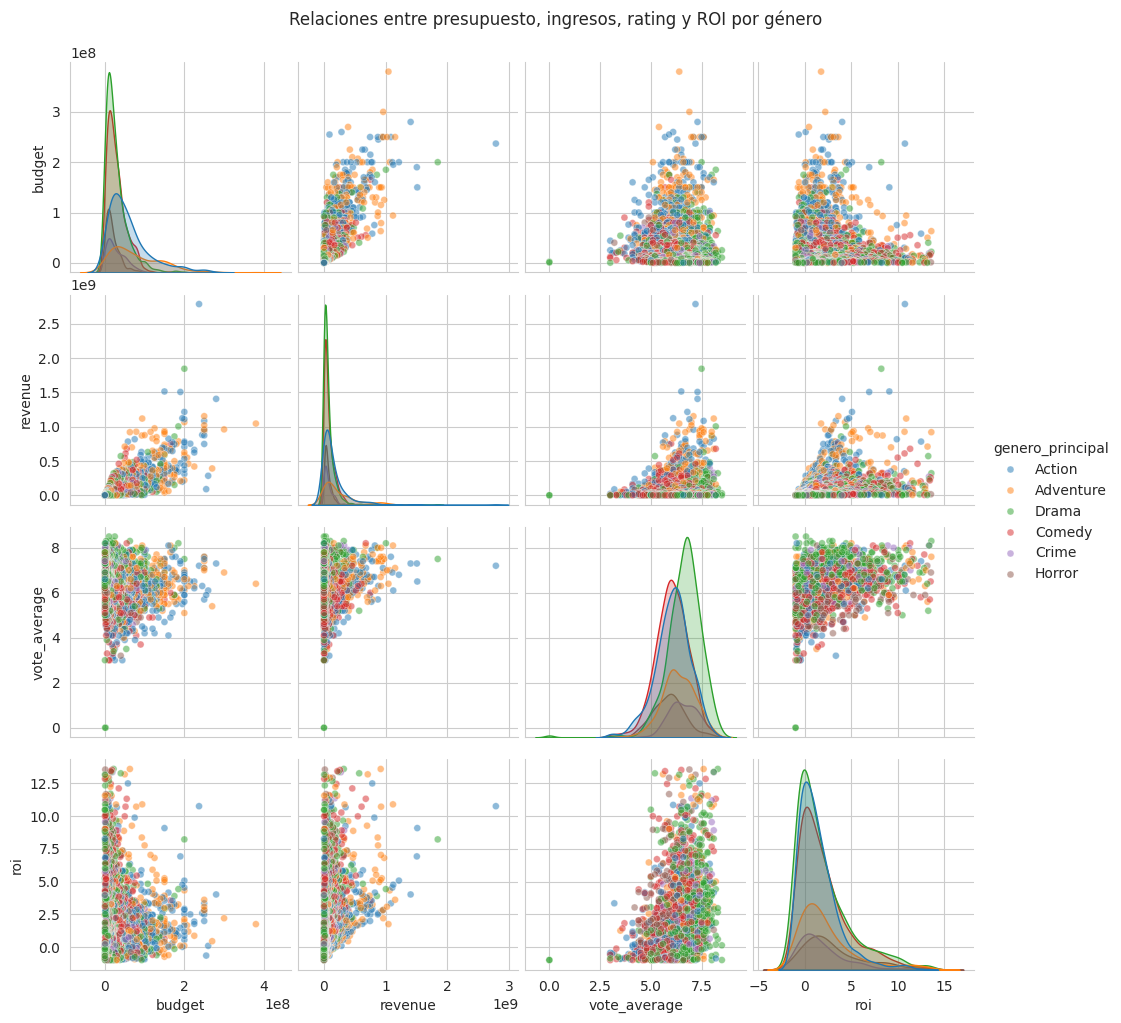

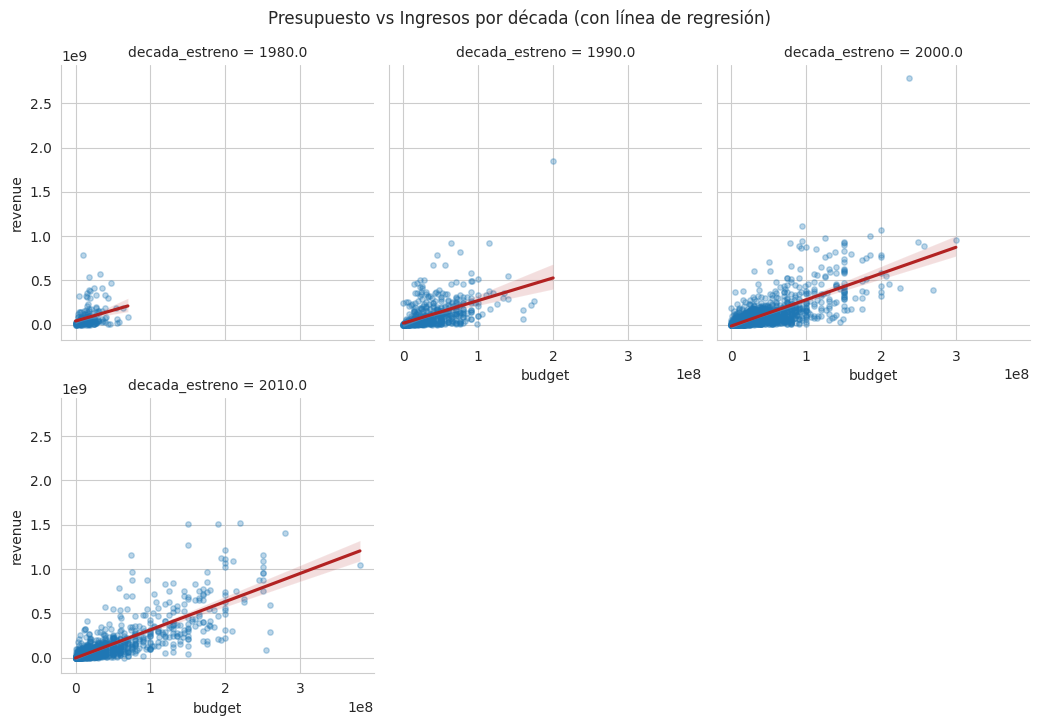

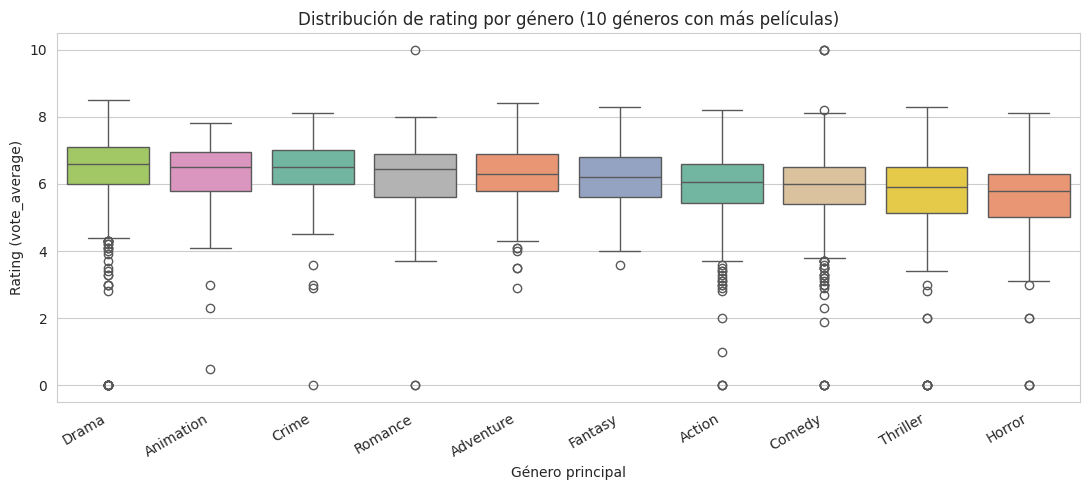


CONCLUSIONES DEL ANÁLISIS

1. ASIMETRÍA EN PRESUPUESTO E INGRESOS
   La media de presupuesto ($37M) es notablemente mayor que la
   mediana ($23M) — confirma que un grupo reducido de
   superproducciones distorsiona el promedio. Mismo patrón en
   ingresos ($117M media vs $52M mediana).

2. EL ROI ES ENGAÑOSO SI NO SE MIRA CON CUIDADO
   Géneros como Drama y Horror muestran ROI PROMEDIO
   absurdamente alto (miles de %) por un puñado de películas de
   presupuesto casi nulo (ej. "Modern Times", budget=$1). La
   MEDIANA cuenta una historia mucho más realista: una película
   de Horror típica apenas triplica su inversión (mediana 2.73),
   no miles de veces.

3. POPULARIDAD Y RECAUDACIÓN VAN DE LA MANO, EL RATING NO TANTO
   La correlación más fuerte del dataset es entre vote_count y
   popularity (0.78): cuanta más gente vio la película, más
   "popular" aparece. Pero vote_average (el rating en sí) casi
   no correlaciona con budget (0.02) — gastar más NO garantiza
   mejor recepción 

In [6]:
# ============================================================
# BLOQUE 5 — VISUALIZACIÓN (SEABORN)
# Proyecto: Análisis de películas TMDB 5000
# ============================================================
#
# Este bloque asume que ya corriste los Bloques 1 a 4, y que
# tenés en memoria 'df_final' y 'df_con_roi'.
#
# Decisión importante ANTES de graficar: en el Bloque 4 vimos
# que 'roi' tiene outliers extremos (máximo ~8.5 millones,
# producto de presupuestos casi nulos como "Modern Times" con
# budget=$1). Si graficamos roi sin filtrar, un solo punto
# aplasta toda la nube de datos contra un eje y el gráfico
# queda ilegible. Por eso recortamos a un rango razonable SOLO
# para visualización (no modificamos el dato real, esto es
# puramente para que el gráfico se pueda leer).
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sns.set_style('whitegrid')

# ------------------------------------------------------------
# 5.1 — Preparar un subset legible para pairplot
# ------------------------------------------------------------
# Tomamos los 6 géneros con más películas (de la tabla del
# Bloque 4) para no saturar el gráfico de colores. Con 21
# géneros distintos, la leyenda y los colores se vuelven
# imposibles de distinguir.

generos_top = df_final['genero_principal'].value_counts().head(6).index.tolist()
print("Géneros incluidos en el pairplot:", generos_top)

df_pairplot = df_final[df_final['genero_principal'].isin(generos_top)].copy()

# Recortamos ROI al percentil 95 SOLO para esta visualización,
# y solo entre películas con ROI calculable (budget/revenue reales).
df_pairplot = df_pairplot.dropna(subset=['roi'])
limite_roi = df_pairplot['roi'].quantile(0.95)
df_pairplot = df_pairplot[df_pairplot['roi'] <= limite_roi]

print(f"Límite de ROI aplicado (percentil 95): {limite_roi:.2f}")
print(f"Películas en el pairplot tras el recorte: {len(df_pairplot)}")

# ------------------------------------------------------------
# 5.2 — sns.pairplot(): relaciones entre variables numéricas
# ------------------------------------------------------------
# pairplot grafica TODAS las combinaciones de pares de columnas
# numéricas en una grilla, coloreando por una categórica (hue).
# Es la forma más rápida de "barrer" varias relaciones a la vez
# antes de elegir cuáles profundizar con lmplot.

columnas_pairplot = ['budget', 'revenue', 'vote_average', 'roi']

grafico_pairplot = sns.pairplot(
    df_pairplot,
    vars=columnas_pairplot,
    hue='genero_principal',
    palette='tab10',
    diag_kind='kde',  # en la diagonal, curva de densidad en vez de histograma
    plot_kws={'alpha': 0.5, 's': 25}  # transparencia: ayuda cuando hay puntos superpuestos
)
grafico_pairplot.fig.suptitle('Relaciones entre presupuesto, ingresos, rating y ROI por género', y=1.02)
plt.savefig('pairplot_peliculas.png', dpi=120, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 5.3 — sns.lmplot(): presupuesto vs ingresos con regresión
# ------------------------------------------------------------
# lmplot agrega una línea de regresión lineal sobre el scatter,
# más una banda de confianza. col='decada_estreno' nos permite
# comparar visualmente si la relación budget-revenue cambió
# entre décadas, todo en una sola llamada (sin loops manuales).

df_lmplot = df_final.dropna(subset=['budget', 'revenue', 'decada_estreno'])
df_lmplot = df_lmplot[df_lmplot['decada_estreno'] >= 1980]  # décadas con muestra suficiente

grafico_lmplot = sns.lmplot(
    data=df_lmplot,
    x='budget',
    y='revenue',
    col='decada_estreno',
    col_wrap=3,
    height=3.5,
    scatter_kws={'alpha': 0.3, 's': 15},
    line_kws={'color': 'firebrick'}
)
grafico_lmplot.fig.suptitle('Presupuesto vs Ingresos por década (con línea de regresión)', y=1.03)
plt.savefig('lmplot_presupuesto_ingresos.png', dpi=120, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 5.4 — Boxplot: distribución de rating por género
# ------------------------------------------------------------
# El boxplot complementa al pairplot: mientras el pairplot
# muestra relaciones entre DOS variables, el boxplot se enfoca
# en la distribución completa de UNA sola variable (rating)
# separada por categoría, mostrando mediana, rango y outliers.

generos_top10 = df_final['genero_principal'].value_counts().head(10).index.tolist()
df_boxplot = df_final[df_final['genero_principal'].isin(generos_top10)]

# Ordenamos los géneros por su rating mediano, para que el
# gráfico se lea de mejor a peor de izquierda a derecha.
orden_por_mediana = (
    df_boxplot.groupby('genero_principal')['vote_average']
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(11, 5))
sns.boxplot(
    data=df_boxplot,
    x='genero_principal',
    y='vote_average',
    order=orden_por_mediana,
    hue='genero_principal',
    palette='Set2',
    legend=False
)
plt.title('Distribución de rating por género (10 géneros con más películas)')
plt.xlabel('Género principal')
plt.ylabel('Rating (vote_average)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('boxplot_rating_genero.png', dpi=120, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 5.5 — Conclusiones del análisis
# ------------------------------------------------------------
print("""
================================================================
CONCLUSIONES DEL ANÁLISIS
================================================================

1. ASIMETRÍA EN PRESUPUESTO E INGRESOS
   La media de presupuesto ($37M) es notablemente mayor que la
   mediana ($23M) — confirma que un grupo reducido de
   superproducciones distorsiona el promedio. Mismo patrón en
   ingresos ($117M media vs $52M mediana).

2. EL ROI ES ENGAÑOSO SI NO SE MIRA CON CUIDADO
   Géneros como Drama y Horror muestran ROI PROMEDIO
   absurdamente alto (miles de %) por un puñado de películas de
   presupuesto casi nulo (ej. "Modern Times", budget=$1). La
   MEDIANA cuenta una historia mucho más realista: una película
   de Horror típica apenas triplica su inversión (mediana 2.73),
   no miles de veces.

3. POPULARIDAD Y RECAUDACIÓN VAN DE LA MANO, EL RATING NO TANTO
   La correlación más fuerte del dataset es entre vote_count y
   popularity (0.78): cuanta más gente vio la película, más
   "popular" aparece. Pero vote_average (el rating en sí) casi
   no correlaciona con budget (0.02) — gastar más NO garantiza
   mejor recepción crítica/de audiencia.

4. EL RATING PROMEDIO BAJA CON EL TIEMPO
   De 7.4 en películas de 1910 a 5.86 en la década de 2010. Esto
   probablemente refleja sesgo de selección: solo las películas
   viejas que se recuerdan y catalogan tienden a ser las
   "buenas", mientras que el catálogo reciente incluye mucho
   más contenido mediocre o de nicho.

5. EL ROI NO ESTÁ RELACIONADO CON NINGUNA OTRA VARIABLE
   Su correlación con budget, revenue, popularity y rating es
   prácticamente cero en todos los casos. El éxito relativo de
   una película (cuánto multiplica su inversión) parece
   depender de factores que este dataset no captura
   (marketing, fecha de estreno, competencia, boca a boca),
   no de cuánto costó hacerla.
================================================================
""")